# 07 — GSV Pipeline: Matching & Evaluation

Demonstrates the skyline matching pipeline and evaluates results:

1. Load pre-computed evaluation results
2. Compare matching approaches (baseline, bandpass NCC, RRF)
3. Analyze error distributions and confidence gating
4. Per-pano deep dive with profile visualization
5. Generate summary figures

Data source: `data/street_view/gsv_improve_eval_results.json`
Produced by: `scripts/gsv_improve_eval.py`

In [1]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))

### Load evaluation results

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = here()
JSON_PATH = ROOT / "data" / "street_view" / "gsv_improve_eval_results.json"
results = json.loads(JSON_PATH.read_text())["results"]
n = len(results)
print(f"{n} panoramas loaded")

68 panoramas loaded


### 1. Method comparison — summary table

In [3]:
def stats(es):
    es = np.asarray(es, float)
    es = es[np.isfinite(es)]
    return dict(
        N=len(es),
        median_km=np.median(es) / 1e3,
        p100=np.mean(es < 100),
        p1k=np.mean(es < 1000),
        p10k=np.mean(es < 10000),
    )

SC = ["baseline", "bp28", "bp316", "rrf"]
hdr = f"{'scorer':<10} {'N':>3} {'median':>8} {'<100m':>7} {'<1km':>7} {'<10km':>7}"
print(hdr)
print("-" * len(hdr))
for s in SC:
    r = stats([x[f"err_{s}"] for x in results])
    print(f"{s:<10} {r['N']:>3} {r['median_km']:>6.1f}km {r['p100']:>6.1%} {r['p1k']:>6.1%} {r['p10k']:>6.1%}")

orc = stats([min(x[f"err_{s}"] for s in SC) for x in results])
print(f"{'oracle':<10} {orc['N']:>3} {orc['median_km']:>6.1f}km {orc['p100']:>6.1%} {orc['p1k']:>6.1%} {orc['p10k']:>6.1%}")

wide = [x for x in results if x["coverage_deg"] >= 200]
print(f"\n--- Wide-FOV subset ({len(wide)} panos, >=200°) ---")
for s in SC:
    r = stats([x[f"err_{s}"] for x in wide])
    print(f"{s:<10} {r['N']:>3} {r['median_km']:>6.1f}km {r['p100']:>6.1%} {r['p1k']:>6.1%} {r['p10k']:>6.1%}")

scorer       N   median   <100m    <1km   <10km
-----------------------------------------------
baseline    68   15.4km   8.8%  11.8%  32.4%
bp28        68   18.3km   7.4%   8.8%  16.2%
bp316       68   14.1km   8.8%  10.3%  29.4%
rrf         68   15.8km  11.8%  13.2%  23.5%
oracle      68    9.1km  13.2%  14.7%  57.4%

--- Wide-FOV subset (25 panos, >=200°) ---
baseline    25   15.3km  20.0%  24.0%  44.0%
bp28        25   16.0km  20.0%  20.0%  32.0%
bp316       25   12.8km  24.0%  28.0%  44.0%
rrf         25   14.4km  28.0%  28.0%  40.0%


### 2. Error CDF — all approaches

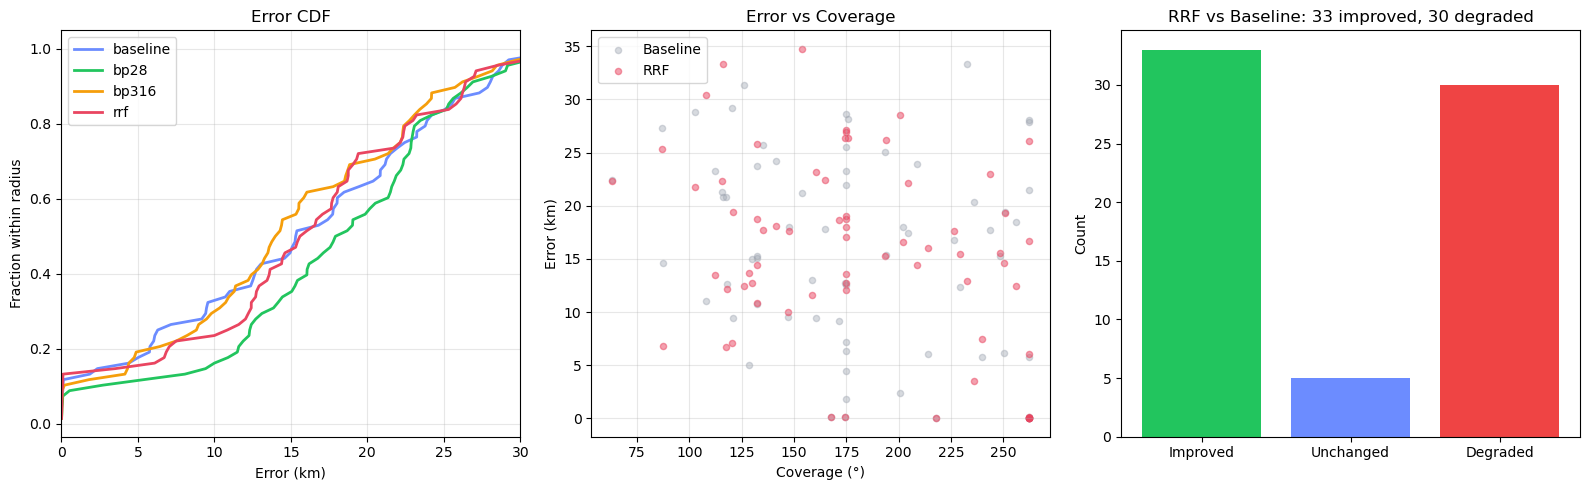

In [4]:
colors = {"baseline": "#6c8cff", "bp28": "#22c55e", "bp316": "#f59e0b", "rrf": "#e94560"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CDF
for s in SC:
    errs = np.sort([x[f"err_{s}"] for x in results]) / 1000
    cdf = np.arange(1, n + 1) / n
    axes[0].plot(errs, cdf, label=s, color=colors[s], linewidth=2)
axes[0].set_xlabel("Error (km)")
axes[0].set_ylabel("Fraction within radius")
axes[0].set_title("Error CDF")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 30)

# Scatter: RRF vs coverage
coverages = [x["coverage_deg"] for x in results]
rrf_errs = [x["err_rrf"] / 1000 for x in results]
base_errs = [x["err_baseline"] / 1000 for x in results]
axes[1].scatter(coverages, base_errs, alpha=0.4, s=20, color="#9ca3af", label="Baseline")
axes[1].scatter(coverages, rrf_errs, alpha=0.5, s=20, color="#e94560", label="RRF")
axes[1].set_xlabel("Coverage (°)")
axes[1].set_ylabel("Error (km)")
axes[1].set_title("Error vs Coverage")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Improvement counts
ratios = [x["err_rrf"] / x["err_baseline"] for x in results if x["err_baseline"] > 0]
improved = sum(1 for r in ratios if r < 1)
degraded = sum(1 for r in ratios if r > 1)
tied = sum(1 for r in ratios if r == 1)
axes[2].bar(["Improved", "Unchanged", "Degraded"], [improved, tied, degraded],
            color=["#22c55e", "#6c8cff", "#ef4444"])
axes[2].set_ylabel("Count")
axes[2].set_title(f"RRF vs Baseline: {improved} improved, {degraded} degraded")

plt.tight_layout()
plt.show()

### 3. Confidence gating

In [5]:
def gate(name, subset):
    errs = np.array([x["err_rrf"] for x in subset], float)
    errs = errs[np.isfinite(errs)]
    print(f"{name:<32} N={len(errs):>2}  <100m={np.mean(errs<100):>6.1%}  "
          f"<1km={np.mean(errs<1000):>6.1%}  median={np.median(errs):>6.0f}m")

gate("all panos (no gate)", results)
gate("consensus only (rrf_votes >= 3)", [x for x in results if x["rrf_votes"] >= 3])
gate("wide-FOV only (>= 200°)", wide)
gate("wide-FOV + consensus", [x for x in wide if x["rrf_votes"] >= 3])

all panos (no gate)              N=68  <100m= 11.8%  <1km= 13.2%  median= 15818m
consensus only (rrf_votes >= 3)  N=10  <100m= 60.0%  <1km= 70.0%  median=    42m
wide-FOV only (>= 200°)          N=25  <100m= 28.0%  <1km= 28.0%  median= 14445m
wide-FOV + consensus             N= 7  <100m= 85.7%  <1km= 85.7%  median=    33m


### 4. Per-pano deep dive

In [6]:
# Pick a successful and a failed case
hits = sorted([x for x in results if x["err_rrf"] < 1000], key=lambda x: x["err_rrf"])
misses = sorted([x for x in results if x["err_rrf"] > 5000], key=lambda x: x["err_rrf"])

if hits:
    print(f"Best match: {hits[0]['pano_id'][:20]}... error={hits[0]['err_rrf']:.0f}m")
if misses:
    print(f"Worst match: {misses[-1]['pano_id'][:20]}... error={misses[-1]['err_rrf']:.0f}m")

Best match: 45TvC0DOQFASM7NjOc-V... error=11m
Worst match: 0j4fexEfmglJpoz4pfOh... error=34764m


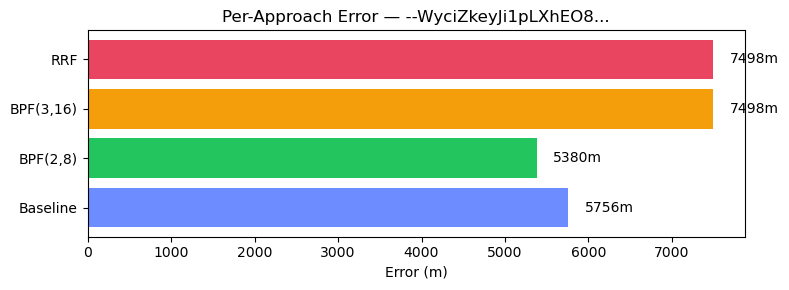

In [7]:
# Bar chart comparison for a specific pano
sample = results[0]
methods = ["Baseline", "BPF(2,8)", "BPF(3,16)", "RRF"]
errs = [sample["err_baseline"], sample["err_bp28"],
        sample["err_bp316"], sample["err_rrf"]]

fig, ax = plt.subplots(figsize=(8, 3))
clrs = ["#6c8cff", "#22c55e", "#f59e0b", "#e94560"]
bars = ax.barh(methods, errs, color=clrs)
ax.set_xlabel("Error (m)")
ax.set_title(f"Per-Approach Error — {sample['pano_id'][:20]}...")
for bar, err in zip(bars, errs):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f"{err:.0f}m", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### 5. Show actual GSV crops with error info

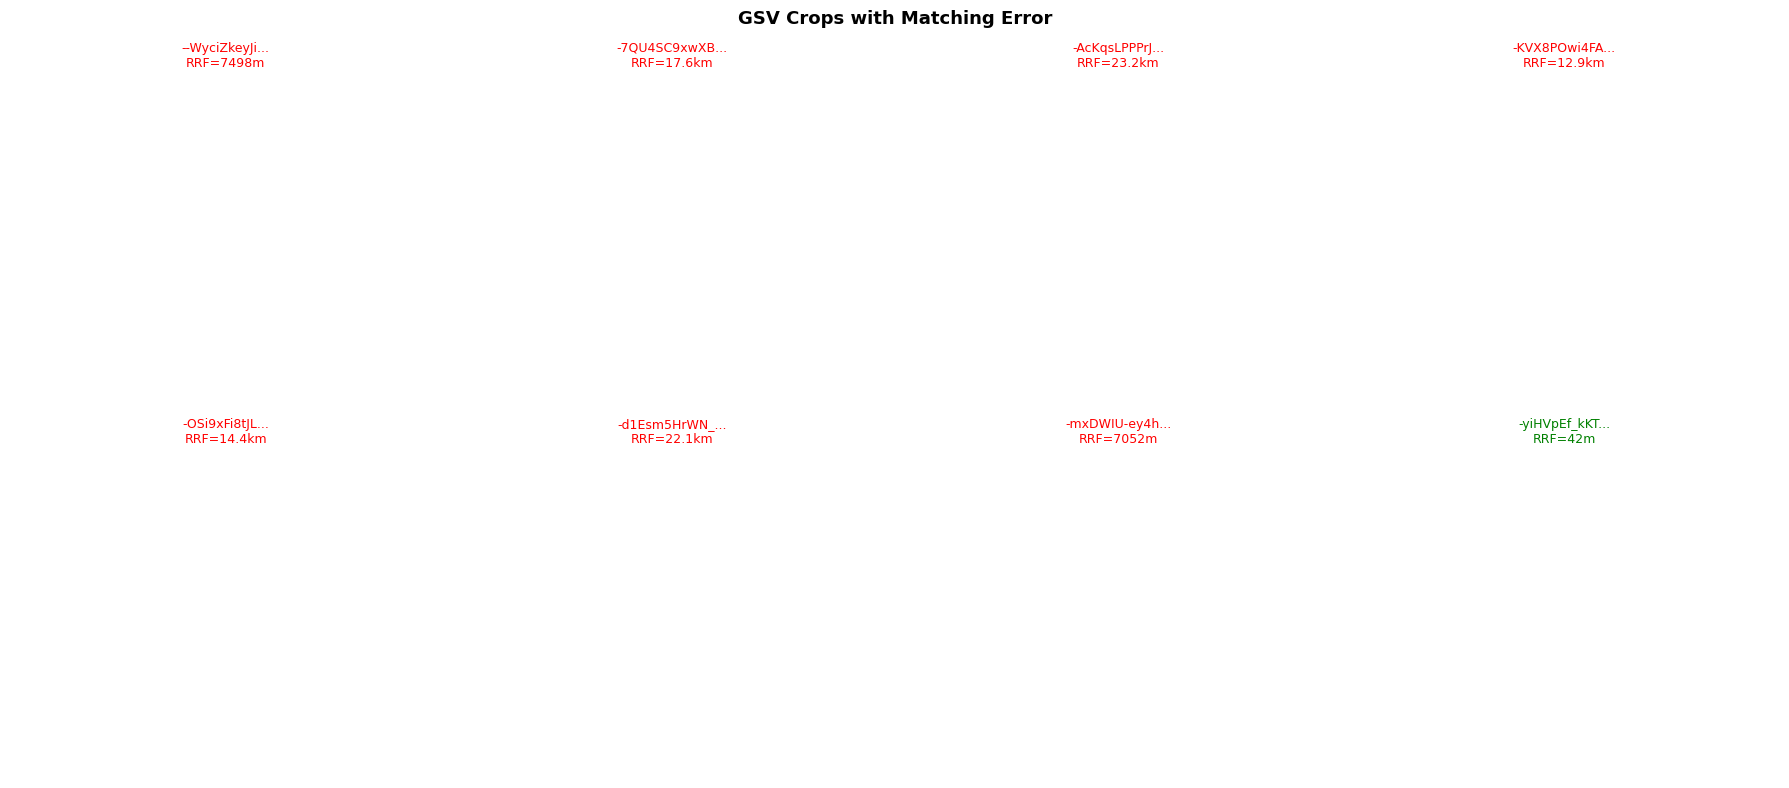

In [8]:
from PIL import Image
import os

CROPS_DIR = ROOT / "data" / "street_view" / "gsv_crops"

# Show first 8 panos with their errors
show_ids = [x["pano_id"] for x in results[:8]]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (sid, ax) in enumerate(zip(show_ids, axes.flat)):
    crop_path = CROPS_DIR / f"{sid}.png"
    if crop_path.exists():
        img = np.array(Image.open(crop_path).convert("RGB"))
        ax.imshow(img)
    r = results[i]
    err_str = f"{r['err_rrf']:.0f}m" if r['err_rrf'] < 10000 else f"{r['err_rrf']/1000:.1f}km"
    color = "green" if r["err_rrf"] < 500 else ("orange" if r["err_rrf"] < 5000 else "red")
    ax.set_title(f"{sid[:12]}...\nRRF={err_str}", fontsize=9, color=color)
    ax.axis("off")
plt.suptitle("GSV Crops with Matching Error", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6. Load end-to-end results (auto vs annotated)

End-to-end results: 1367 total, 701 auto-valid, 30 annot-valid


ValueError: supplied range of [0.011887775822489054, inf] is not finite

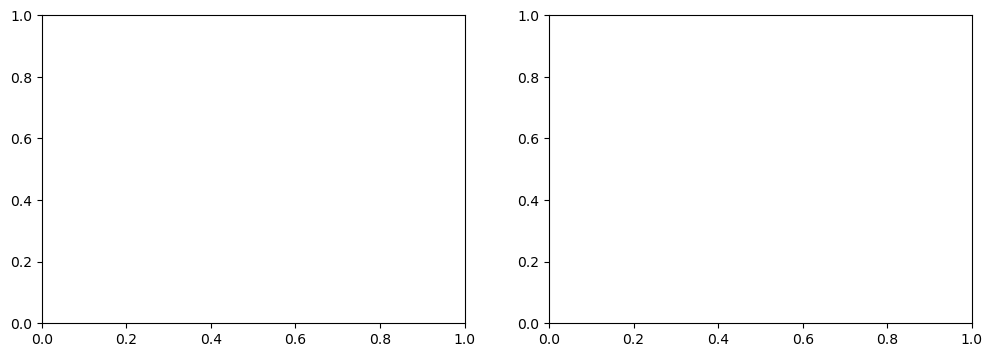

In [9]:
e2e_path = ROOT / "data" / "street_view" / "end_to_end_results.json"
if e2e_path.exists():
    e2e = json.loads(e2e_path.read_text())
    print(f"End-to-end results: {e2e['n_total']} total, "
          f"{e2e['auto_valid_n']} auto-valid, {e2e['annot_valid_n']} annot-valid")
    
    e2e_results = e2e["results"]
    
    # Auto vs annotated errors
    auto_rrf = [x["auto_errs"]["rrf"] for x in e2e_results if x.get("auto_errs")]
    annot_rrf = [x["annot_errs"]["rrf"] for x in e2e_results if x.get("annot_errs")]
    
    if auto_rrf and annot_rrf:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(np.array(auto_rrf) / 1000, bins=30, color="#6c8cff", alpha=0.7, label="Auto")
        axes[0].hist(np.array(annot_rrf) / 1000, bins=30, color="#e94560", alpha=0.7, label="Annotated")
        axes[0].set_xlabel("Error (km)")
        axes[0].set_ylabel("Count")
        axes[0].set_title("End-to-End: Auto vs Annotated")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Improvement from annotation
        common = [(x["auto_errs"]["rrf"], x["annot_errs"]["rrf"])
                  for x in e2e_results
                  if x.get("auto_errs") and x.get("annot_errs")]
        auto_arr = np.array([c[0] for c in common])
        annot_arr = np.array([c[1] for c in common])
        better = np.sum(annot_arr < auto_arr)
        worse = np.sum(annot_arr > auto_arr)
        axes[1].scatter(auto_arr / 1000, annot_arr / 1000, alpha=0.5, s=20)
        lim = max(auto_arr.max(), annot_arr.max()) / 1000
        axes[1].plot([0, lim], [0, lim], "r--", alpha=0.5)
        axes[1].set_xlabel("Auto Error (km)")
        axes[1].set_ylabel("Annotated Error (km)")
        axes[1].set_title(f"Auto vs Annotated: annotation improves {better}/{len(common)}")
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("end_to_end_results.json not found")